In [1]:
# dataset @NABIL from Nepal Stock Exchange

In [2]:
#importing pandas which is used to read data
import pandas as pd

In [3]:
df = pd.read_csv("NABIL.csv")
df

,Symbol,Date,Open,High,Low,Close,Volume
0,NABIL,3/20/2011,1200.0,1190.0,1160.0,1170.0,"1,000,811.00"
1,NABIL,3/24/2011,1162.0,1178.0,1150.0,1153.0,"412,649.00"
2,NABIL,3/25/2011,1153.0,1174.0,1145.0,1174.0,"807,507.00"
3,NABIL,3/27/2011,1174.0,1160.0,1120.0,1147.0,"1,619,270.00"
4,NABIL,3/28/2011,1147.0,1150.0,1110.0,1132.0,"393,534.00"
...,...,...,...,...,...,...,...
3120,NABIL,12/1/2024,537.3,540.0,534.1,536.0,"42,627,477.80"
3121,NABIL,12/2/2024,546.7,546.7,533.0,534.0,"43,132,809.20"
3122,NABIL,12/3/2024,544.6,544.6,530.2,532.0,"33,351,241.10"
3123,NABIL,12/4/2024,542.6,542.6,530.0,530.0,"36,964,486.10"


In [4]:
# Displaying the date and closing price of that date
df = df[['Date', 'Close']]
df
df['Date']

0       3/20/2011
1       3/24/2011
2       3/25/2011
3       3/27/2011
4       3/28/2011
          ...    
3120    12/1/2024
3121    12/2/2024
3122    12/3/2024
3123    12/4/2024
3124    12/5/2024
Name: Date, Length: 3125, dtype: object

In [5]:
#since date is object datatype, we have to convert it into datetime
import datetime
def str_to_datetime(s):
    split = s.split('/')
    year, month, day = int(split[2]), int(split[0]), int(split[1])
    return datetime.datetime(year= year, month = month, day = day)

datetime_object = str_to_datetime('12/5/2024')
datetime_object

datetime.datetime(2024, 12, 5, 0, 0)

In [6]:
#Applying str_to_daytime to each and every date values
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

C:\Users\BBhuwan\AppData\Local\Temp\ipykernel_16668\2340046373.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = df['Date'].apply(str_to_datetime)


0      2011-03-20
1      2011-03-24
2      2011-03-25
3      2011-03-27
4      2011-03-28
          ...    
3120   2024-12-01
3121   2024-12-02
3122   2024-12-03
3123   2024-12-04
3124   2024-12-05
Name: Date, Length: 3125, dtype: datetime64[ns]

In [7]:
# We have to now convert the date into index, since date will be related to that date
df.index = df.pop('Date')
df

,Close
Date,
2011-03-20,1170.0
2011-03-24,1153.0
2011-03-25,1174.0
2011-03-27,1147.0
2011-03-28,1132.0
...,...
2024-12-01,536.0
2024-12-02,534.0
2024-12-03,532.0


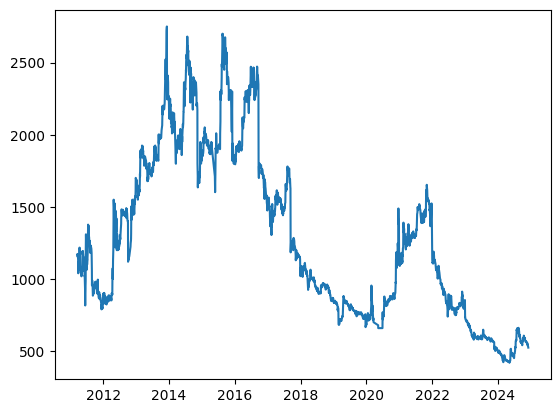

In [8]:
#importing matplotlib and ploting the past closing prices along with its date
import matplotlib.pyplot as plt
plt.plot(df.index, df['Close'])

In [9]:
import numpy as np

def df_to_windowed_df(df, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date = str_to_datetime(last_date_str)
    
    target_date = first_date

    dates = []
    X, Y = [], []
    
    last_time = False
    while True:
        # Select the appropriate window
        df_subset = df.loc[:target_date].tail(n+1)
        
        # Check if the subset is valid
        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return
        
        # Extract features and target
        values = df_subset['Close'].to_numpy()
        x, y = values[:-1], values[-1]
        
        dates.append(target_date)
        X.append(x)
        Y.append(y)
        
        # Move to the next target date
        next_week = df.loc[target_date:target_date+datetime.timedelta(days=7)]
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
        next_date_str = next_datetime_str.split('T')[0]
        year_month_day = next_date_str.split('-')
        year, month, day = year_month_day
        next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))
        if last_time:
            break
    
        target_date = next_date

        if target_date == last_date:
            last_time = True
    
    ret_df = pd.DataFrame({})
    ret_df['Target Date'] = dates
    
    X = np.array(X)
    for i in range(0,n):
        X[:,i]
        ret_df[f'Target-{n-i}'] = X[:, i]
    ret_df['Target'] = Y
    
    return ret_df




In [ ]:
windowed_df = df_to_windowed_df(df, 
                                '3/28/2011', 
                                '12/5/2024', 
                                n=3)
windowed_df

In [ ]:
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    dates = df_as_np[:,0]

    middle_matrix = df_as_np[:,1:-1]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    Y = df_as_np[:, -1]
    return dates, X.astype(np.float32), Y.astype(np.float32)
dates, X, y = windowed_df_to_date_X_y (windowed_df)
dates.shape, X.shape, y.shape

NameError: name 'windowed_df' is not defined